# DESI BGS Simulations

In [1]:
import fitsio
import numpy as np
import healpy as hp
import pandas as pd
import seaborn as sns
from astropy.table import Table, vstack, MaskedColumn
import matplotlib.pyplot as plt
%matplotlib inline

from Simulation.simulMap import *
from Simulation.fitMap import *
from Simulation.lumMag_sampling import *
from Simulation.mappers import DensityMapper, FracCovMapper

In [2]:
nside = 128
npix= hp.nside2npix(nside)
area_deg2 = hp.nside2pixarea(nside, degrees=True)
print("Number of pixels = {}".format(npix))
print("Surface of a pixel = {} deg^2".format(area_deg2))

Number of pixels = 196608
Surface of a pixel = 0.2098234113027917 deg^2


## FRACCOV

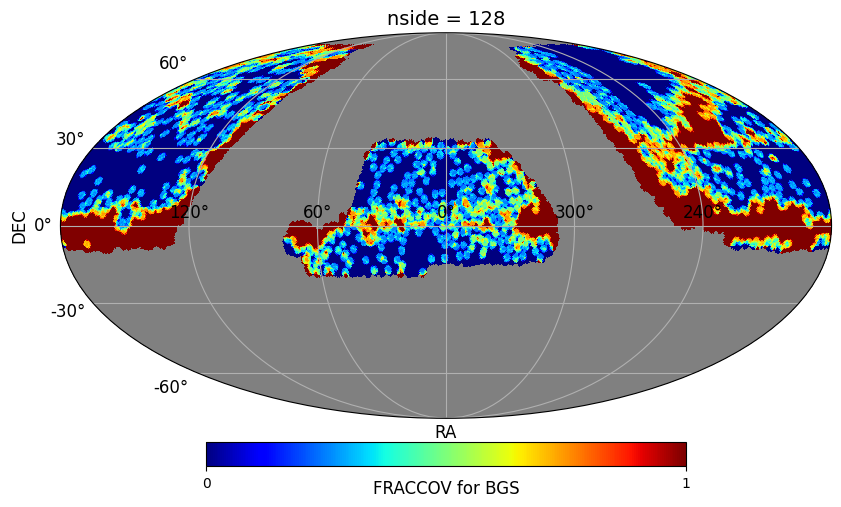

In [3]:
#File name:
DIR = "data/Data DESI/"
FILE_DR1 = DIR + "dr1-main-bright.fits"

sources="BGS"

outputDIR = DIR + f"DESI Figures/DESI DR1 {sources}/" #to save figures
output_path_data = outputDIR + f"DESI_DR1_{sources}_Data/" #common suffix to every figures
output_path_Simu = outputDIR + f"DESI_DR1_{sources}_Simul/"
suffix_data = f"DESI_DR1_{sources}_Density_map_"
suffix_Simu = f"DESI_DR1_{sources}_Simul_Density_map_"

#Reading file:
DR1_Mapper = FracCovMapper.read(FILE_DR1, nest=True)
DR1_Mapper.get_nside(nside)
DR1_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

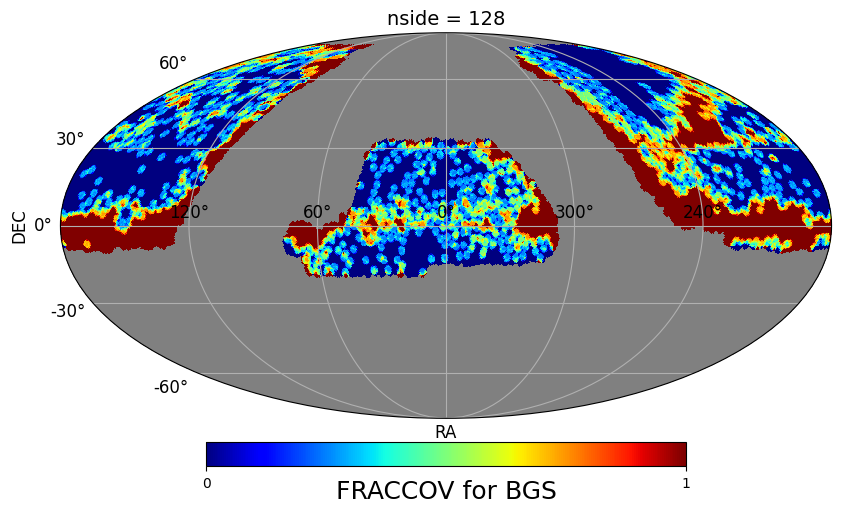

In [4]:
DR1_Mapper._set_instance_settingsPlot(unit_size = 18) #to customize the unit of plots.
DR1_Mapper.plot(use_map = "nside", title = f"nside = {DR1_Mapper.nside}")

## Density

### From DESI data

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.712e+07 (χ²/ndof = 87.1) │              Nfcn = 430              │
│ EDM = 5.64e-06 (Goal: 0.0002)    │           time = 13.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  205.65   │   0.09    │   -0.09    │    0.09    │    0    │         │       │
│ 1 │ A    │ 634.2e-3  │  0.7e-3   │  -0.7e-3   │   0.7e-3   │    0    │    1    │       │
│ 2 │ ra   │  229.90   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -50.72   │   0.05    │   -0.05    │    0.05    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.09   │   0.09    │  -0.7e-3  │  0.7e-3   │   -0.07   │   0.07    │   -0.05   │   0.05    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │  0.00759  26.2e-6   -0.001  -0.0025 │
│   A │  26.2e-6 4.44e-07   0.8e-6 -10.9e-6 │
│  ra │   -0.001   0.8e-6  0.00491   0.0013 │
│ dec │  -0.0025 -10.9e-6   0.0013  0.00277 │
└─────┴─────────────────────────────────────┘

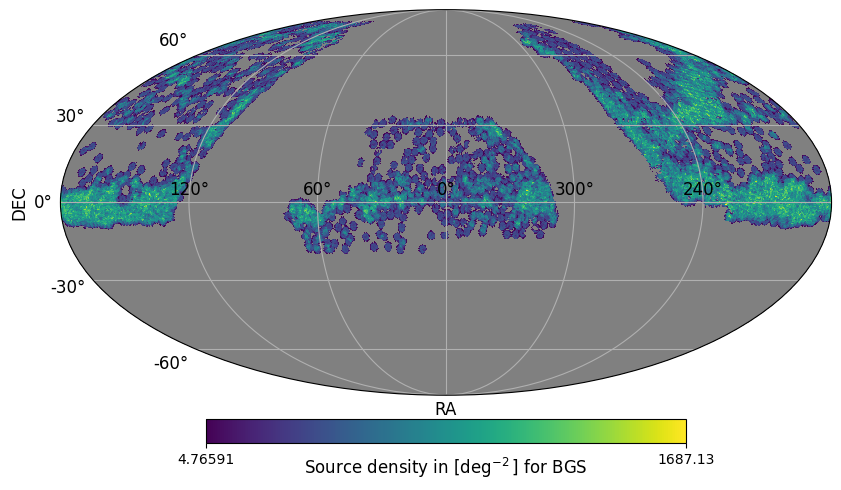

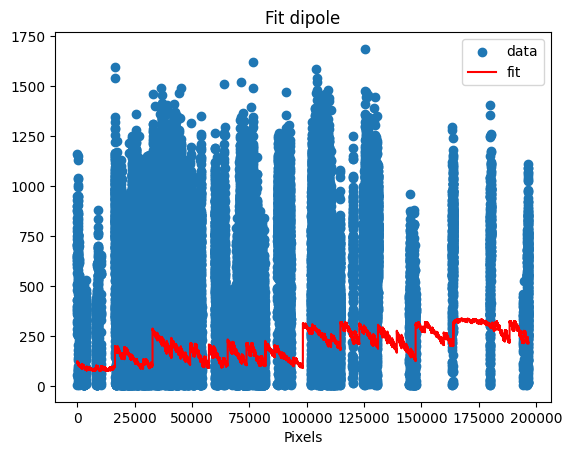

In [4]:
#File names:
FILE_NGC = DIR + "BGS_ANY_NGC_clustering.dat.fits"
FILE_SGC = DIR + "BGS_ANY_SGC_clustering.dat.fits"

#Reading files:
NGC_Mapper = DensityMapper.read(FILE_NGC, nside=nside, nest=True)
SGC_Mapper = DensityMapper.read(FILE_SGC, nside=nside, nest=True)
ALL_Mapper = NGC_Mapper.add(SGC_Mapper)
ALL_Mapper._set_suffixTextPlot(unit = sources) #to customize the unit of plots.
ALL_Mapper.set_mask()
# ALL_Mapper.plot("Masked")
# get_savefig(plt, output_path_data, suffix_data+"mask0");

#Fitting dipole:
init =  (1000, 1, 100, -10)
m = ALL_Mapper.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.93e+06 (χ²/ndof = 40.3)  │              Nfcn = 330              │
│ EDM = 2.12e-05 (Goal: 0.0002)    │           time = 10.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  383.30   │   0.15    │   -0.15    │    0.15    │    0    │         │       │
│ 1 │ A    │ 580.6e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │  216.78   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -44.06   │   0.06    │   -0.06    │    0.06    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.15   │   0.15    │  -0.6e-3  │  0.6e-3   │   -0.07   │   0.07    │   -0.06   │   0.06    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0218  22.4e-6    0.000  -0.0053 │
│   A │  22.4e-6 3.69e-07   4.6e-6 -11.8e-6 │
│  ra │    0.000   4.6e-6  0.00433  -0.0000 │
│ dec │  -0.0053 -11.8e-6  -0.0000  0.00351 │
└─────┴─────────────────────────────────────┘

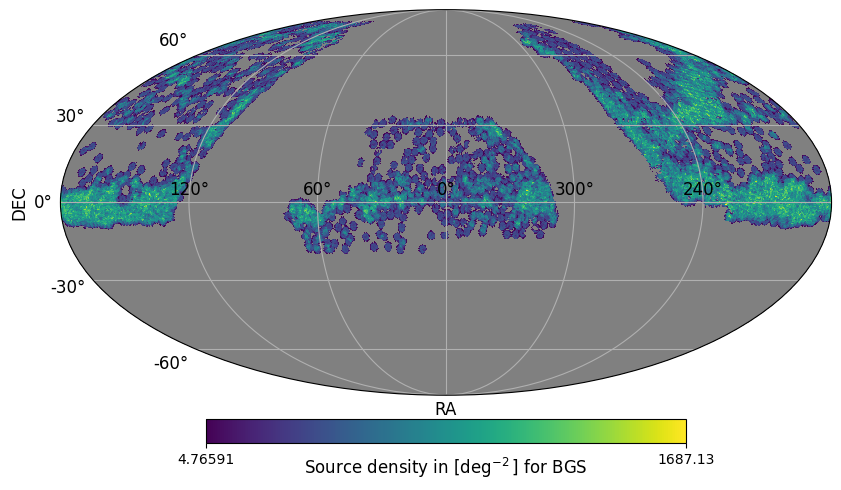

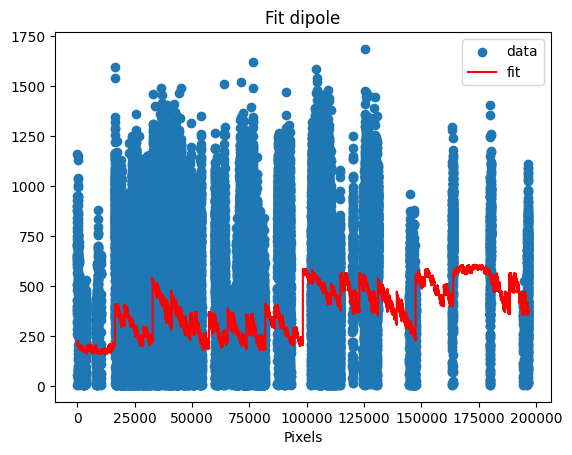

In [5]:
init =  (1000, 1, 100, -10)
m = ALL_Mapper.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From simulation

Total number of sources in the entire sky : 69599232
Theorical number of sources in one pixel : 354


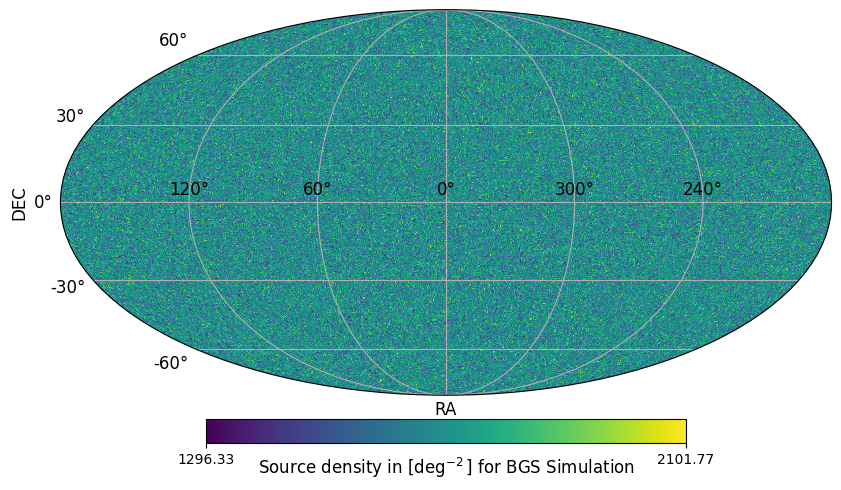

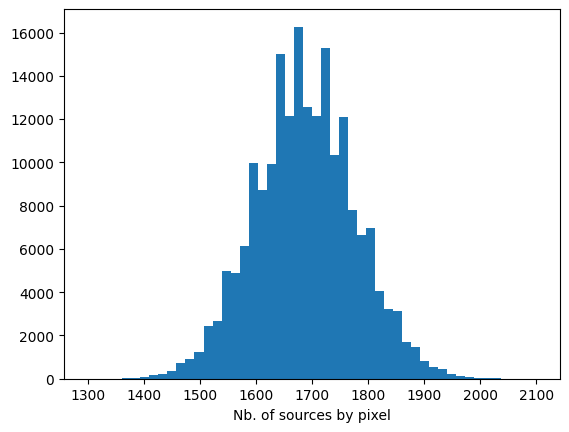

In [6]:
NSource_px_th = int(ALL_Mapper.map.max() * ALL_Mapper.area_deg2)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

#data = generate_lumMag(NSource_px_th*npix, to_table=True)
data = {}
data["RA"], data["DEC"] = generate_raDec(NSource_px_th*npix)
data = Table(data)

simu_Mapper = DensityMapper(data, nside=nside)
simu_Mapper._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper.plot('')

get_hist(simu_Mapper.map, bins=50);

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.391e+05 (χ²/ndof = 1.2)  │              Nfcn = 759              │
│ EDM = 7.49e-05 (Goal: 0.0002)    │           time = 26.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.68198e3 │ 0.00025e3 │ -0.00025e3 │ 0.00025e3  │    0    │         │       │
│ 1 │ A    │  0.67e-3  │  0.29e-3  │  -0.28e-3  │  0.30e-3   │    0    │    1    │       │
│ 2 │ ra   │    240    │    40     │    -50     │     40     │    0    │   360   │       │
│ 3 │ dec  │    65     │    20     │    -27     │     17     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.25   │   0.25    │ -0.28e-3  │  0.30e-3  │    -50    │    40     │    -27    │    17     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │     0.0639  -50.34e-6      -0.47      -1.92 │
│   A │  -50.34e-6   8.47e-08 2.01695e-3 2.87152e-3 │
│  ra │      -0.47 2.01695e-3   1.33e+03     -0.1e3 │
│ dec │      -1.92 2.87152e-3     -0.1e3        425 │
└─────┴─────────────────────────────────────────────┘

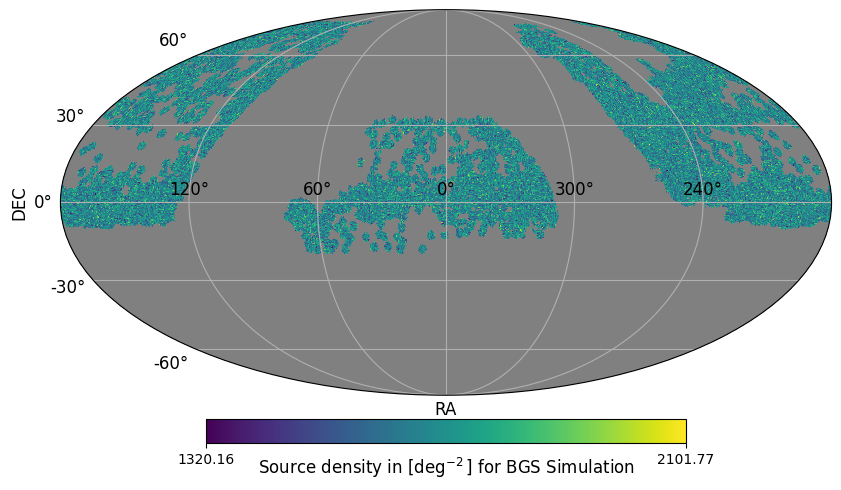

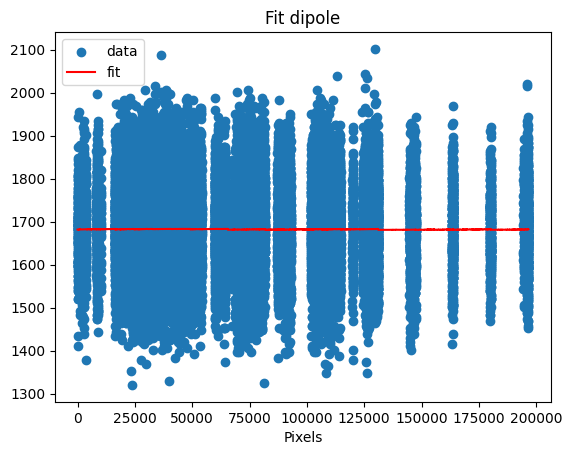

In [7]:
simu_Mapper.set_mask(mask=ALL_Mapper.mapMasked.mask)

init =  (1000, 0, 100, 40)
m = simu_Mapper.fit_dipole("Masked", init)
m

### FRACCOV rescaling

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.135e+07 (χ²/ndof = 159.5)│              Nfcn = 442              │
│ EDM = 6.09e-06 (Goal: 0.0002)    │           time = 14.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  397.88   │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 1 │ A    │ 660.9e-3  │  0.5e-3   │  -0.5e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │  238.41   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -50.57   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.12   │   0.12    │  -0.5e-3  │  0.5e-3   │   -0.05   │   0.05    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0148 27.27e-6  -0.0011  -0.0027 │
│   A │ 27.27e-6 2.31e-07 -2.10e-6 -5.82e-6 │
│  ra │  -0.0011 -2.10e-6  0.00216   0.0008 │
│ dec │  -0.0027 -5.82e-6   0.0008  0.00152 │
└─────┴─────────────────────────────────────┘

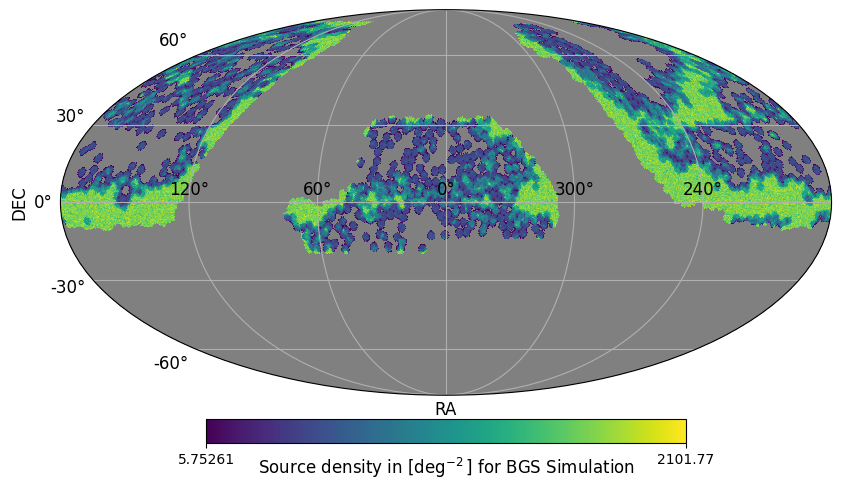

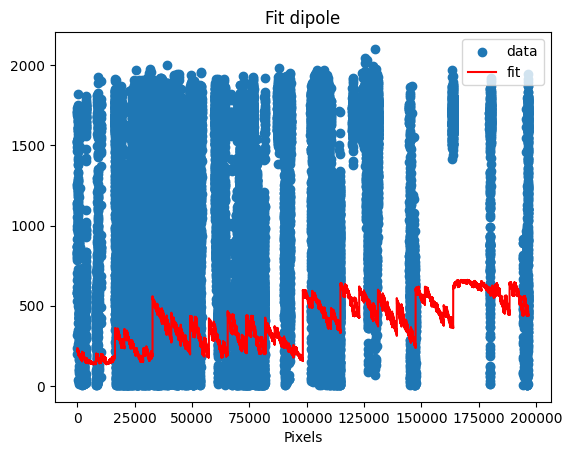

In [8]:
hpmap = simu_Mapper.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_scale = DensityMapper.from_map(hpmap)
simu_Mapper_scale._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_scale.set_mask()
# simu_Mapper_scale.plot("Masked")
# get_savefig(plt, output_path_Simu, suffix_Simu+"mask0");

init =  (1000, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.328e+06 (χ²/ndof = 42.4) │              Nfcn = 290              │
│ EDM = 2.27e-05 (Goal: 0.0002)    │            time = 8.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.05485e3 │ 0.00025e3 │ -0.00025e3 │ 0.00025e3  │    0    │         │       │
│ 1 │ A    │ 492.4e-3  │  0.4e-3   │  -0.4e-3   │   0.4e-3   │    0    │    1    │       │
│ 2 │ ra   │  217.86   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -58.03   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.25   │   0.25    │  -0.4e-3  │  0.4e-3   │   -0.07   │   0.07    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0614 43.15e-6   -0.001  -0.0052 │
│   A │ 43.15e-6  1.8e-07  0.73e-6 -5.39e-6 │
│  ra │   -0.001  0.73e-6  0.00436   0.0005 │
│ dec │  -0.0052 -5.39e-6   0.0005  0.00134 │
└─────┴─────────────────────────────────────┘

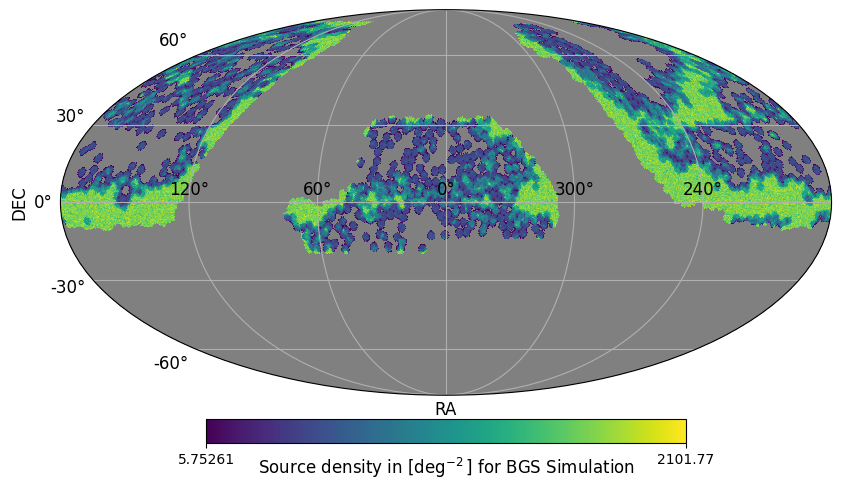

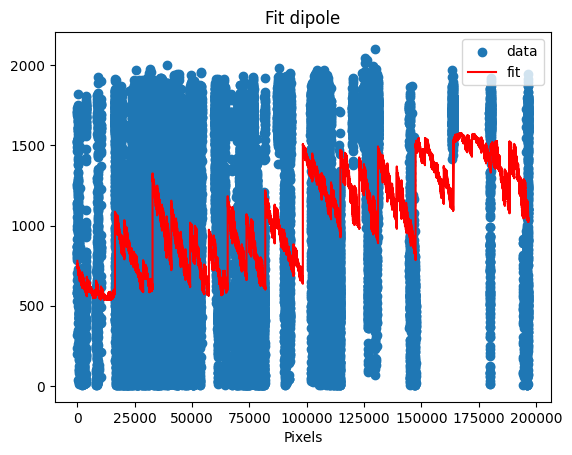

In [9]:
init =  (1000, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

### From Poisson noise

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.135e+07 (χ²/ndof = 159.4)│              Nfcn = 440              │
│ EDM = 5.21e-06 (Goal: 0.0002)    │           time = 14.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  398.42   │   0.12    │   -0.12    │    0.12    │    0    │         │       │
│ 1 │ A    │ 656.9e-3  │  0.5e-3   │  -0.5e-3   │   0.5e-3   │    0    │    1    │       │
│ 2 │ ra   │  238.41   │   0.05    │   -0.05    │    0.05    │    0    │   360   │       │
│ 3 │ dec  │  -50.82   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.12   │   0.12    │  -0.5e-3  │  0.5e-3   │   -0.05   │   0.05    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0149 27.82e-6  -0.0011  -0.0027 │
│   A │ 27.82e-6 2.33e-07 -2.28e-6 -6.00e-6 │
│  ra │  -0.0011 -2.28e-6  0.00222   0.0009 │
│ dec │  -0.0027 -6.00e-6   0.0009  0.00154 │
└─────┴─────────────────────────────────────┘

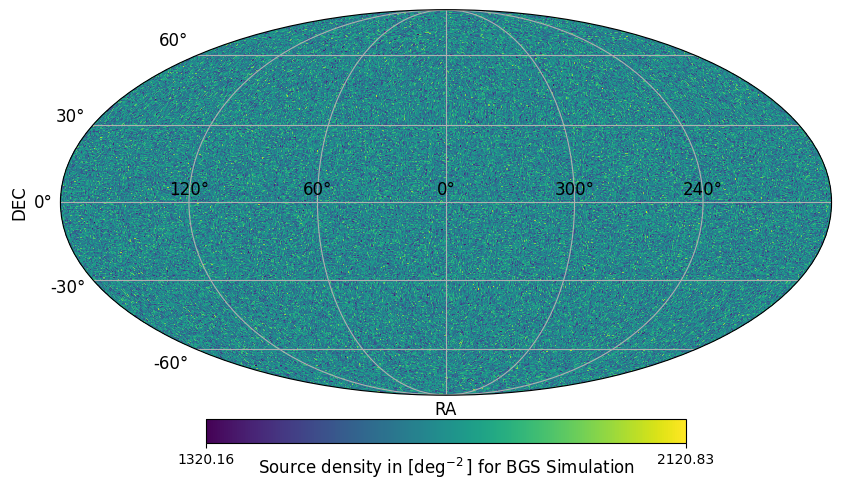

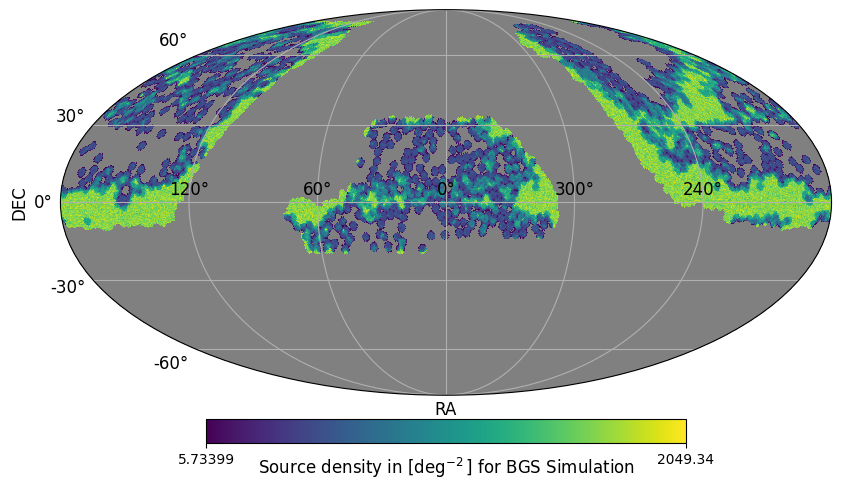

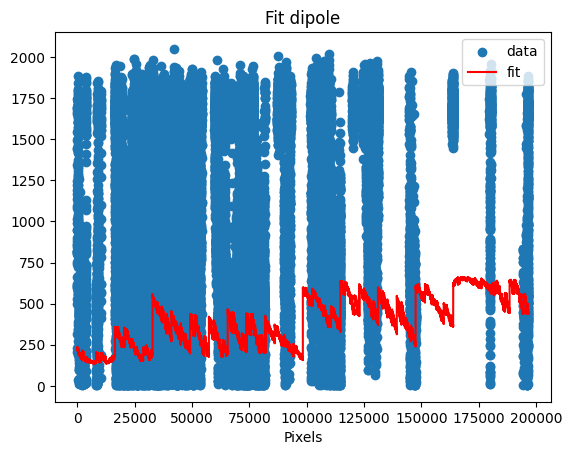

In [10]:
hpmap = np.random.poisson(NSource_px_th, npix)/area_deg2
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.plot('')

hpmap = simu_Mapper_pois.map * DR1_Mapper.FRACCOVnside.filled(0)
hpmap[np.isnan(hpmap)] = 0
simu_Mapper_pois = DensityMapper.from_map(hpmap)
simu_Mapper_pois._set_suffixTextPlot(unit = f"{sources} Simulation") #to customize the unit of plots.
simu_Mapper_pois.set_mask()

init =  (1000, 0, 100, -10)
m = simu_Mapper_pois.fit_dipole("Masked", init)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.34e+06 (χ²/ndof = 42.4)  │              Nfcn = 290              │
│ EDM = 2.64e-05 (Goal: 0.0002)    │            time = 8.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.05532e3 │ 0.00025e3 │ -0.00025e3 │ 0.00025e3  │    0    │         │       │
│ 1 │ A    │ 492.1e-3  │  0.4e-3   │  -0.4e-3   │   0.4e-3   │    0    │    1    │       │
│ 2 │ ra   │  217.84   │   0.07    │   -0.07    │    0.07    │    0    │   360   │       │
│ 3 │ dec  │  -58.14   │   0.04    │   -0.04    │    0.04    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.25   │   0.25    │  -0.4e-3  │  0.4e-3   │   -0.07   │   0.07    │   -0.04   │   0.04    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0614 43.22e-6   -0.001  -0.0052 │
│   A │ 43.22e-6  1.8e-07  0.73e-6 -5.37e-6 │
│  ra │   -0.001  0.73e-6  0.00439   0.0005 │
│ dec │  -0.0052 -5.37e-6   0.0005  0.00134 │
└─────┴─────────────────────────────────────┘

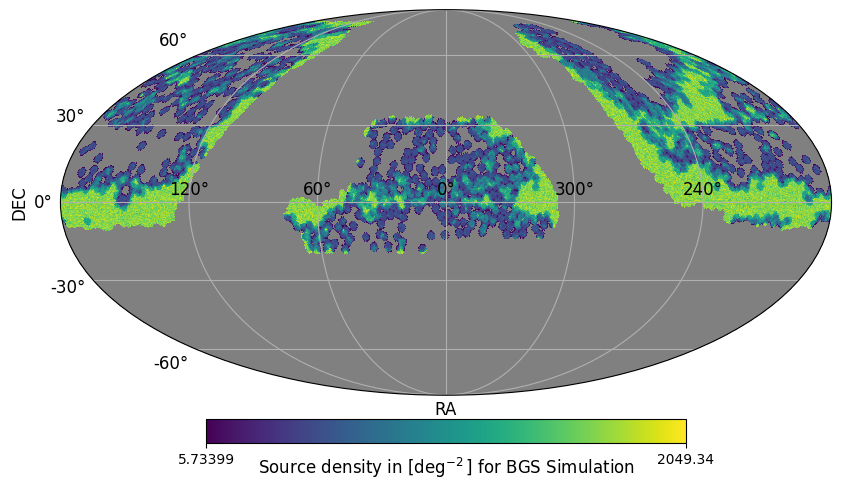

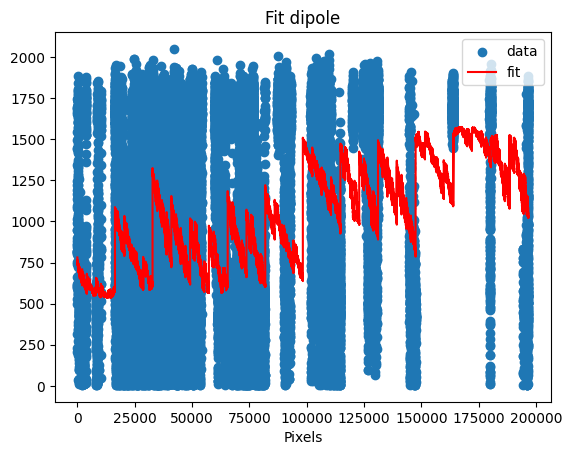

In [11]:
init =  (1000, 0, 100, -10)
m = simu_Mapper_pois.fit_dipole("Masked", init, weights=DR1_Mapper.FRACCOVnside)
m

## FRACCOV cut

### From DESI data

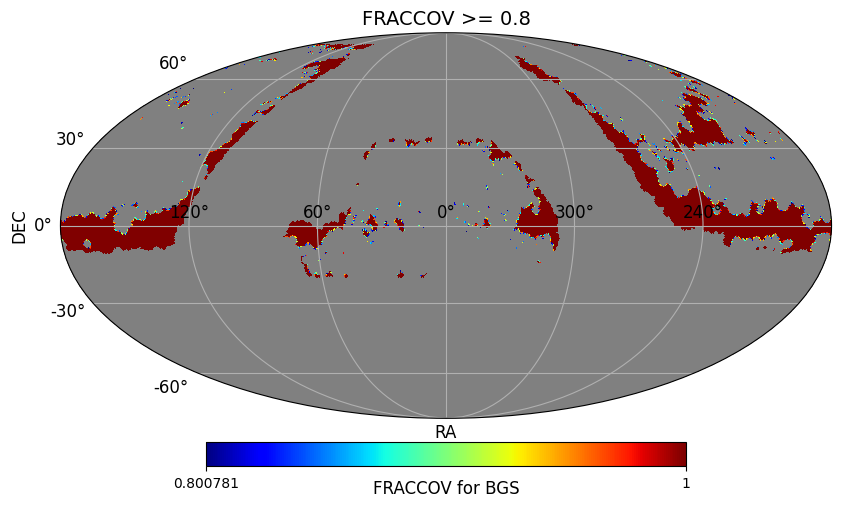

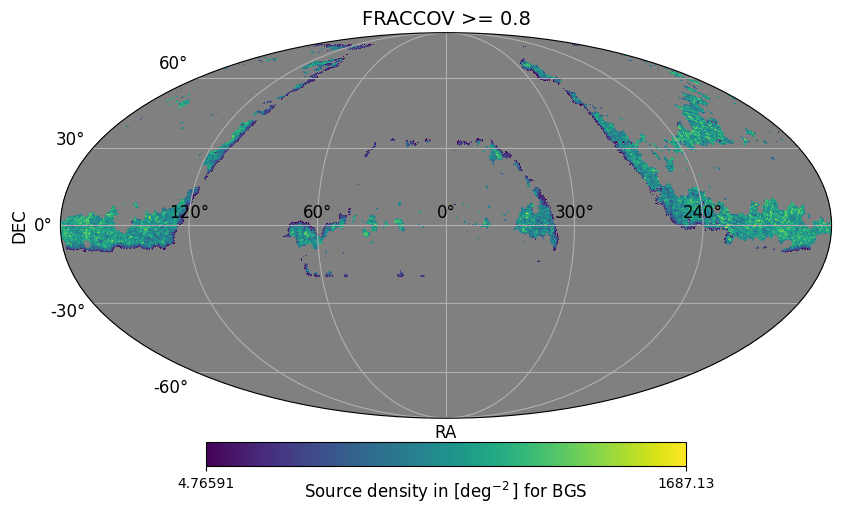

In [12]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'

DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title=title)

ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask)
ALL_Mapper.plot(use_map='Cut', title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.256e+06 (χ²/ndof = 26.7) │              Nfcn = 318              │
│ EDM = 8.77e-07 (Goal: 0.0002)    │           time = 10.3 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  363.86   │   0.20    │   -0.20    │    0.20    │    0    │         │       │
│ 1 │ A    │ 779.7e-3  │  0.8e-3   │  -0.8e-3   │   0.8e-3   │    0    │    1    │       │
│ 2 │ ra   │  207.87   │   0.06    │   -0.06    │    0.06    │    0    │   360   │       │
│ 3 │ dec  │  -25.08   │   0.09    │   -0.08    │    0.09    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.2    │    0.2    │  -0.8e-3  │  0.8e-3   │   -0.06   │   0.06    │   -0.08   │   0.09    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │    0.041 -62.8e-6   0.0024   -0.011 │
│   A │ -62.8e-6 7.19e-07  -0.8e-6   3.9e-6 │
│  ra │   0.0024  -0.8e-6  0.00313  -0.0014 │
│ dec │   -0.011   3.9e-6  -0.0014  0.00724 │
└─────┴─────────────────────────────────────┘

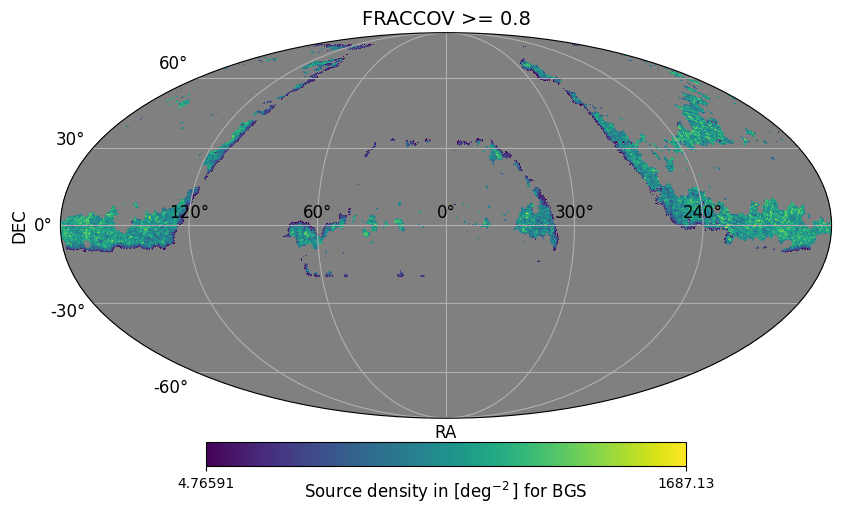

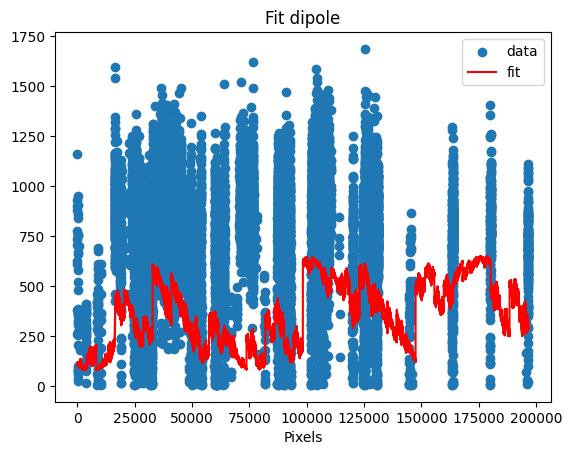

In [13]:
init =  (200, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 5.306e+06 (χ²/ndof = 27.0) │              Nfcn = 289              │
│ EDM = 9.45e-06 (Goal: 0.0002)    │            time = 9.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  366.08   │   0.20    │   -0.20    │    0.20    │    0    │         │       │
│ 1 │ A    │ 771.9e-3  │  0.8e-3   │  -0.8e-3   │   0.8e-3   │    0    │    1    │       │
│ 2 │ ra   │  207.96   │   0.06    │   -0.06    │    0.06    │    0    │   360   │       │
│ 3 │ dec  │  -25.11   │   0.08    │   -0.08    │    0.08    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.2    │    0.2    │  -0.8e-3  │  0.8e-3   │   -0.06   │   0.06    │   -0.08   │   0.08    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────┐
│     │       N*        A       ra      dec │
├─────┼─────────────────────────────────────┤
│  N* │   0.0407 -60.7e-6   0.0024   -0.011 │
│   A │ -60.7e-6 7.01e-07  -0.7e-6   3.5e-6 │
│  ra │   0.0024  -0.7e-6  0.00314  -0.0014 │
│ dec │   -0.011   3.5e-6  -0.0014   0.0072 │
└─────┴─────────────────────────────────────┘

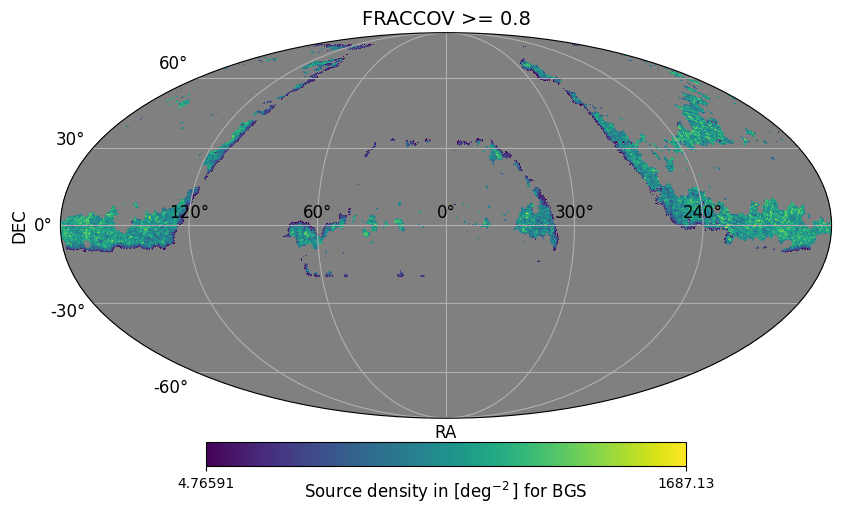

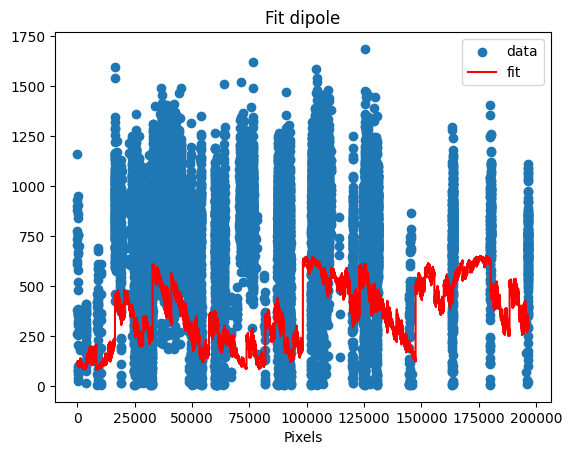

In [14]:
init =  (200, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.166e+05 (χ²/ndof = 0.6)  │              Nfcn = 576              │
│ EDM = 4.65e-05 (Goal: 0.0002)    │           time = 19.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.6634e3  │ 0.0005e3  │ -0.0005e3  │  0.0005e3  │    0    │         │       │
│ 1 │ A    │  19.1e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │   208.5   │    3.5    │    -3.5    │    3.5     │    0    │   360   │       │
│ 3 │ dec  │   -74.0   │    1.2    │    -1.1    │    1.2     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.5    │    0.5    │  -0.6e-3  │  0.6e-3   │   -3.5    │    3.5    │   -1.1    │    1.2    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │     0.216  134.3e-6      0.27     -0.38 │
│   A │  134.3e-6  3.74e-07  489.9e-6 -302.5e-6 │
│  ra │      0.27  489.9e-6      12.2      -0.7 │
│ dec │     -0.38 -302.5e-6      -0.7      1.39 │
└─────┴─────────────────────────────────────────┘

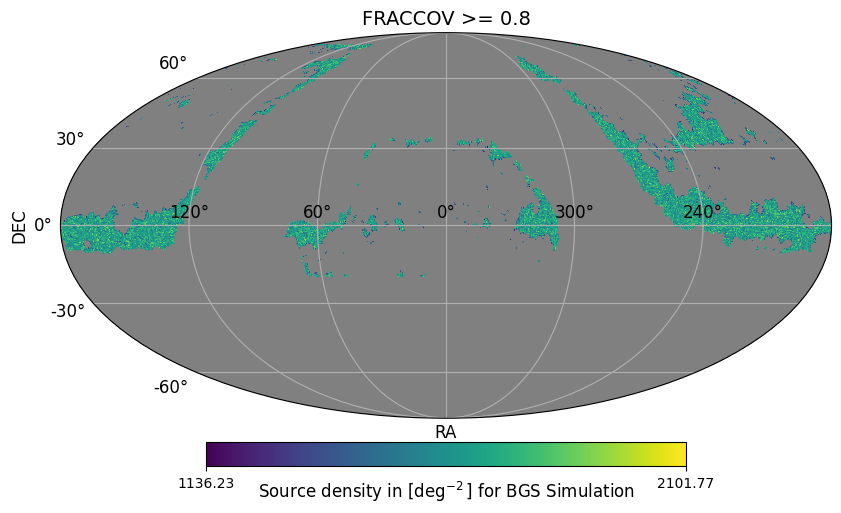

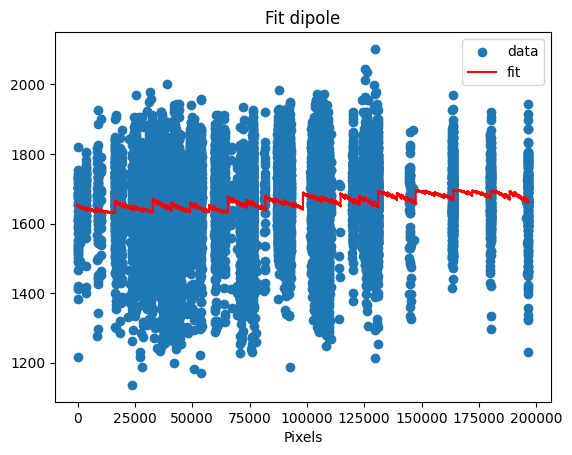

In [15]:
frac_min = 0.8
title = f'FRACCOV >= {frac_min}'
DR1_Mapper.cut_FracCov(frac_min=frac_min)
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask)

init =  (200, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.259e+05 (χ²/ndof = 0.6)  │              Nfcn = 642              │
│ EDM = 1.18e-06 (Goal: 0.0002)    │           time = 21.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.65701e3 │ 0.00032e3 │ -0.00032e3 │ 0.00032e3  │    0    │         │       │
│ 1 │ A    │  10e-12   │8292248e-12│  -10e-12   │8292248e-12 │    0    │    1    │       │
│ 2 │ ra   │    90     │    320    │    -90     │    270     │    0    │   360   │       │
│ 3 │ dec  │    81     │    165    │    -165    │     9      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │  -10e-12  │8292248e-12│    -90    │    270    │   -165    │     9     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │              N*               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│  N* │             0.1     1.46104e-12            -0.0           -0.00 │
│   A │     1.46104e-12        3.24e-16 -66.33026164e-9  -1.67675771e-9 │
│  ra │            -0.0 -66.33026164e-9        9.55e+04             0e3 │
│ dec │           -0.00  -1.67675771e-9             0e3        6.05e+03 │
└─────┴─────────────────────────────────────────────────────────────────┘

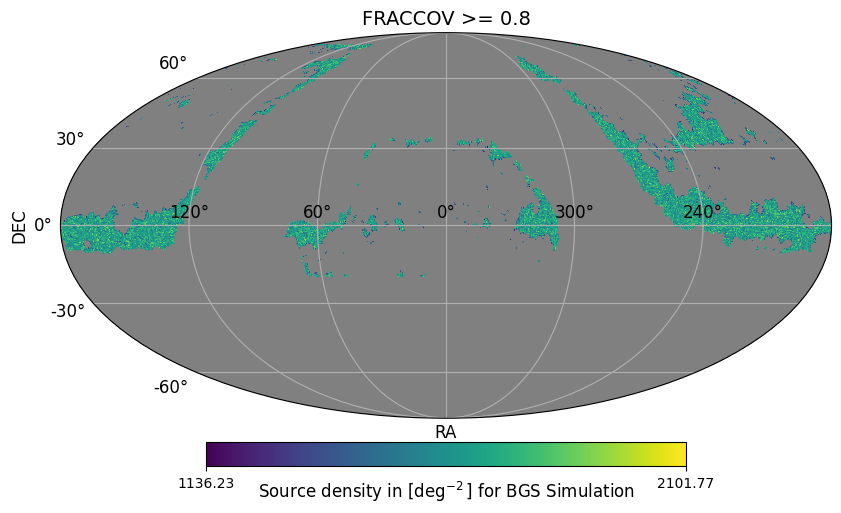

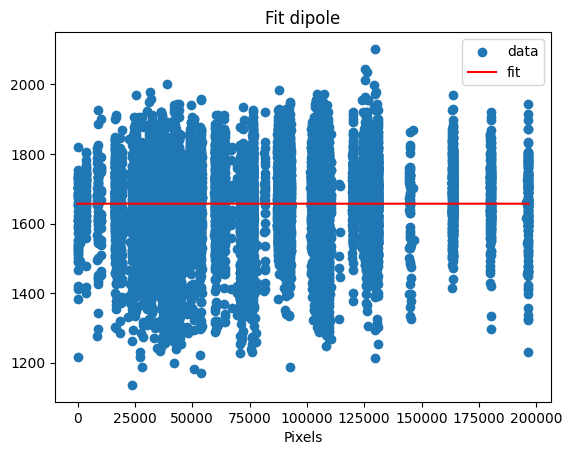

In [16]:
init =  (200, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Density count > min and FRACCOV > frac_min

### From DESI data

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


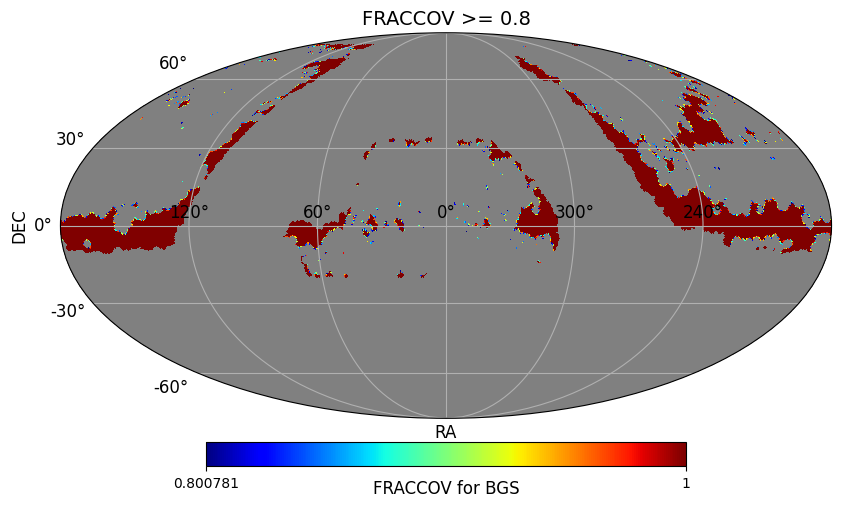

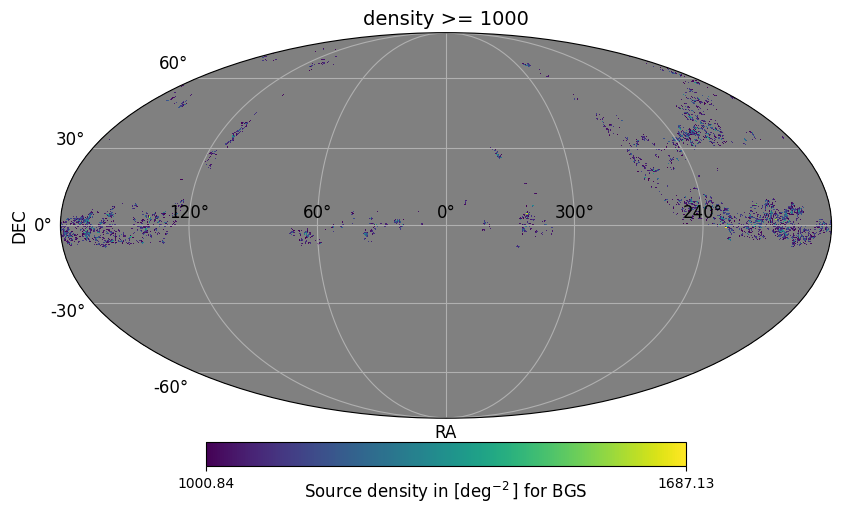

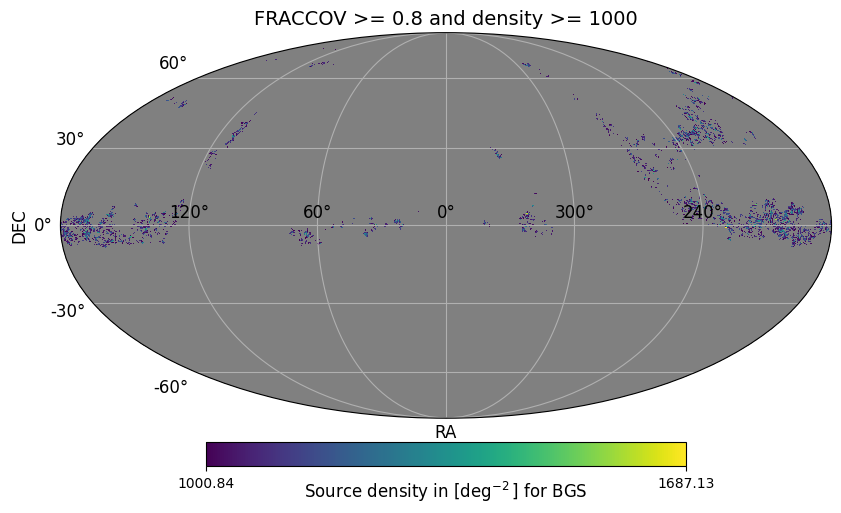

In [17]:
frac_min = 0.8
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 1000
ALL_Mapper.select_bounds(map_min=count_min)
ALL_Mapper.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
ALL_Mapper.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
ALL_Mapper.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.366e+04 (χ²/ndof = 0.1)  │              Nfcn = 614              │
│ EDM = 1.72e-05 (Goal: 0.0002)    │           time = 20.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.1014e3  │ 0.0010e3  │ -0.0010e3  │  0.0010e3  │    0    │         │       │
│ 1 │ A    │  0.0062   │  0.0011   │  -0.0011   │   0.0011   │    0    │    1    │       │
│ 2 │ ra   │    237    │    10     │    -10     │     10     │    0    │   360   │       │
│ 3 │ dec  │    -8     │    18     │    -17     │     19     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -1     │     1     │  -0.0011  │  0.0011   │    -10    │    10     │    -17    │    19     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │       1.09  -410.5e-6        6.3       -9.7 │
│   A │  -410.5e-6   1.19e-06   315.5e-6 -5.3909e-3 │
│  ra │        6.3   315.5e-6        107    -0.06e3 │
│ dec │       -9.7 -5.3909e-3    -0.06e3        342 │
└─────┴─────────────────────────────────────────────┘

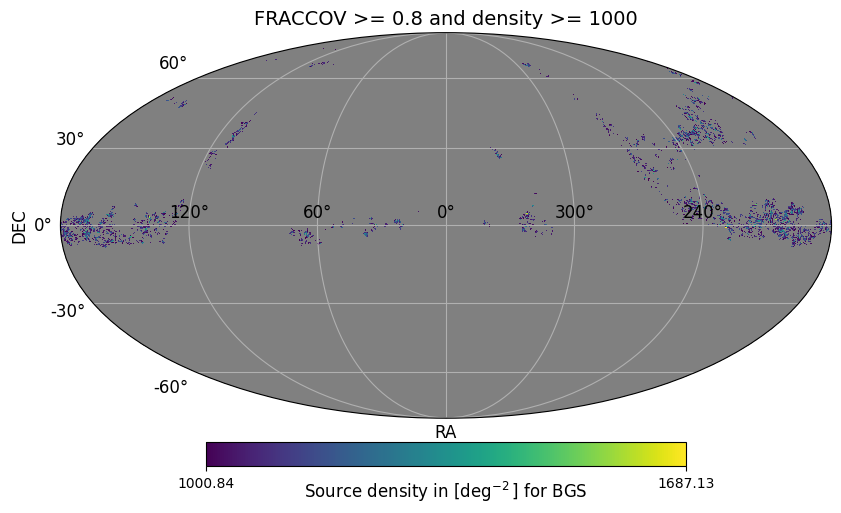

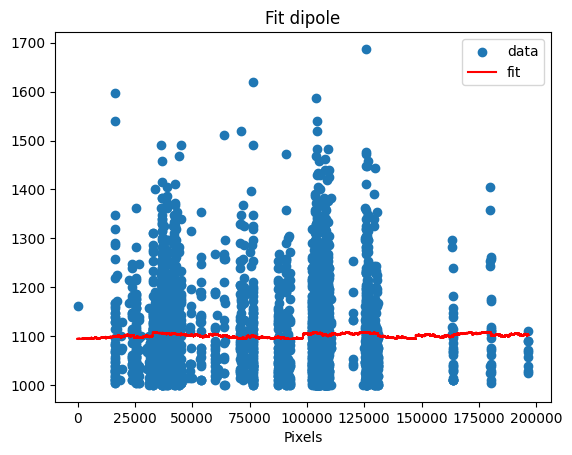

In [18]:
init =  (1000, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.374e+04 (χ²/ndof = 0.1)  │              Nfcn = 623              │
│ EDM = 4.5e-06 (Goal: 0.0002)     │           time = 19.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.1013e3  │ 0.0010e3  │ -0.0010e3  │  0.0010e3  │    0    │         │       │
│ 1 │ A    │  0.0064   │  0.0011   │  -0.0011   │   0.0012   │    0    │    1    │       │
│ 2 │ ra   │    237    │    10     │    -10     │     10     │    0    │   360   │       │
│ 3 │ dec  │    -12    │    17     │    -16     │     18     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -1     │     1     │  -0.0011  │  0.0012   │    -10    │    10     │    -16    │    18     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────┐
│     │         N*          A         ra        dec │
├─────┼─────────────────────────────────────────────┤
│  N* │       1.07  -336.9e-6        6.1       -9.2 │
│   A │  -336.9e-6   1.29e-06   792.6e-6 -7.0310e-3 │
│  ra │        6.1   792.6e-6        101    -0.06e3 │
│ dec │       -9.2 -7.0310e-3    -0.06e3        304 │
└─────┴─────────────────────────────────────────────┘

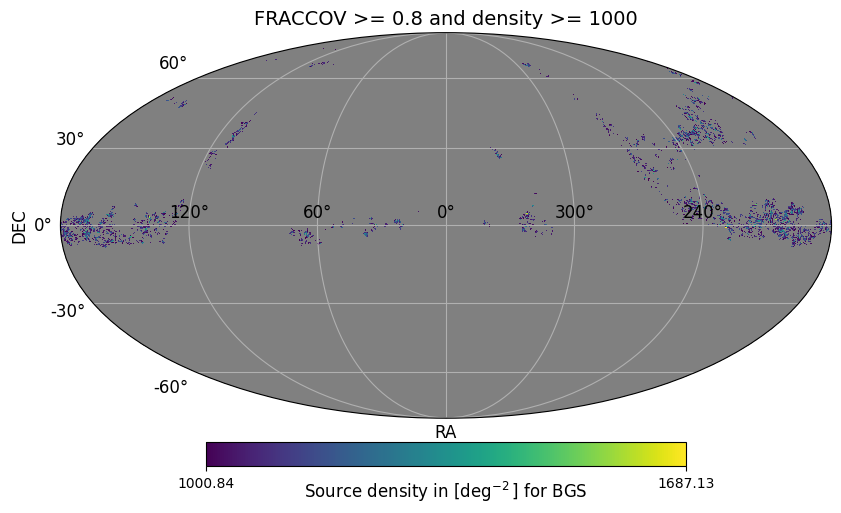

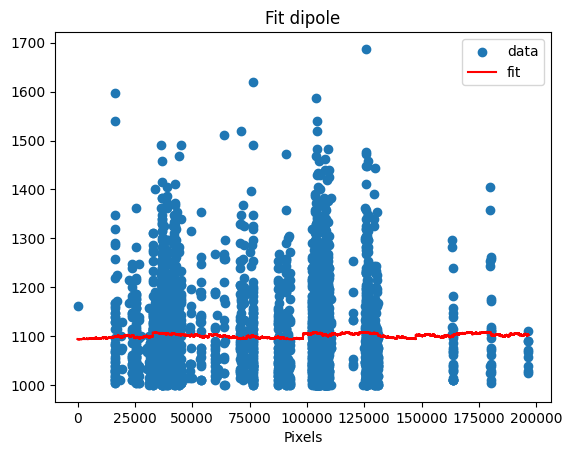

In [19]:
init =  (1000, 0, 100, -10)
m = ALL_Mapper.fit_dipole("Cut", init, title_map=title)
m

### From simulation

Attribut FRACCOVcut already existed and has been replaced.
Attribut map has no attribut mask. Using mask from mapMasked instead.
Attribut mapCut already existed and has been replaced.
Attribut mapCut already existed and has been replaced.


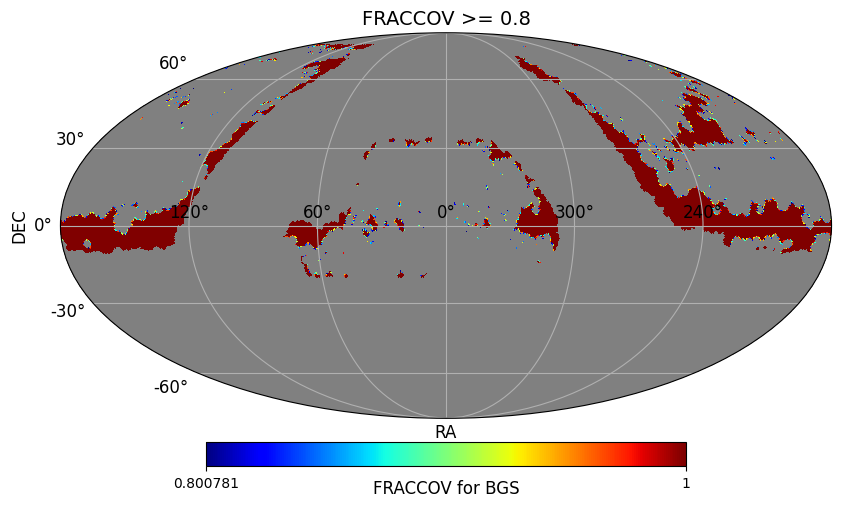

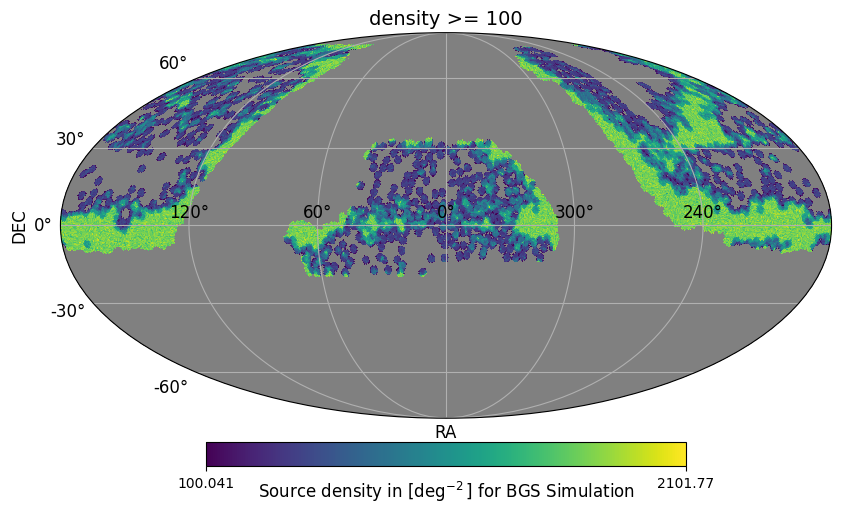

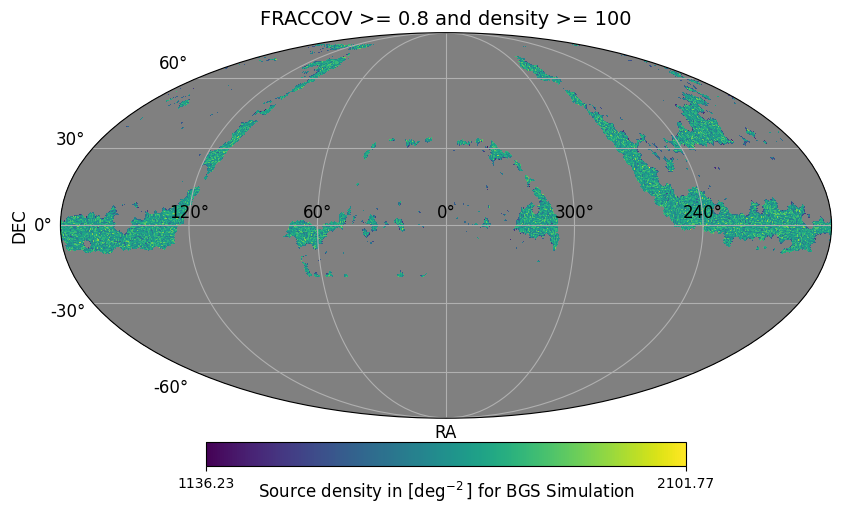

In [20]:
frac_min = 0.8
DR1_Mapper.cut_FracCov(frac_min=frac_min)
DR1_Mapper.plot(use_map="cut", title = f"FRACCOV >= {frac_min}")

count_min = 100
simu_Mapper_scale.select_bounds(map_min=count_min)
simu_Mapper_scale.plot(use_map="Cut", title = f"density >= {count_min}")

title = f'FRACCOV >= {frac_min} and density >= {count_min}'
simu_Mapper_scale.set_cutMask(DR1_Mapper.FRACCOVcut.mask, fromMap="Cut")
simu_Mapper_scale.plot(use_map="Cut", title=title)

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.166e+05 (χ²/ndof = 0.6)  │              Nfcn = 576              │
│ EDM = 4.65e-05 (Goal: 0.0002)    │           time = 17.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.6634e3  │ 0.0005e3  │ -0.0005e3  │  0.0005e3  │    0    │         │       │
│ 1 │ A    │  19.1e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │    0    │    1    │       │
│ 2 │ ra   │   208.5   │    3.5    │    -3.5    │    3.5     │    0    │   360   │       │
│ 3 │ dec  │   -74.0   │    1.2    │    -1.1    │    1.2     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.5    │    0.5    │  -0.6e-3  │  0.6e-3   │   -3.5    │    3.5    │   -1.1    │    1.2    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │     0.216  134.3e-6      0.27     -0.38 │
│   A │  134.3e-6  3.74e-07  489.9e-6 -302.5e-6 │
│  ra │      0.27  489.9e-6      12.2      -0.7 │
│ dec │     -0.38 -302.5e-6      -0.7      1.39 │
└─────┴─────────────────────────────────────────┘

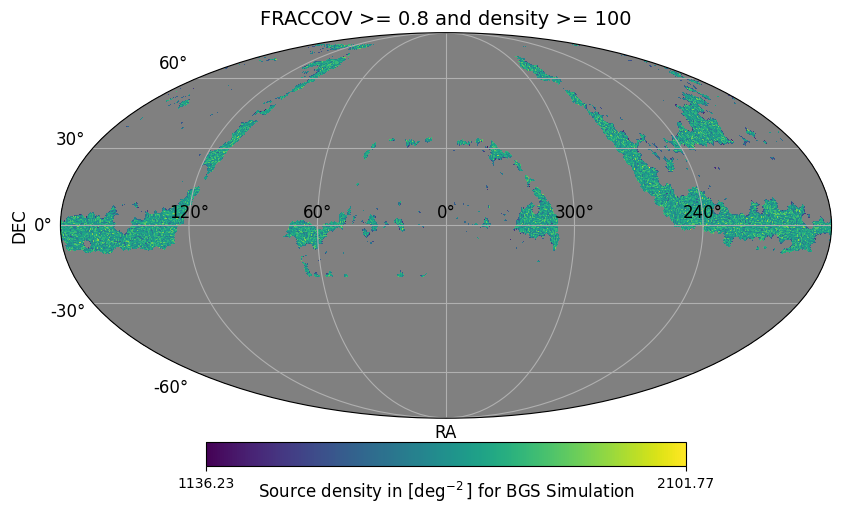

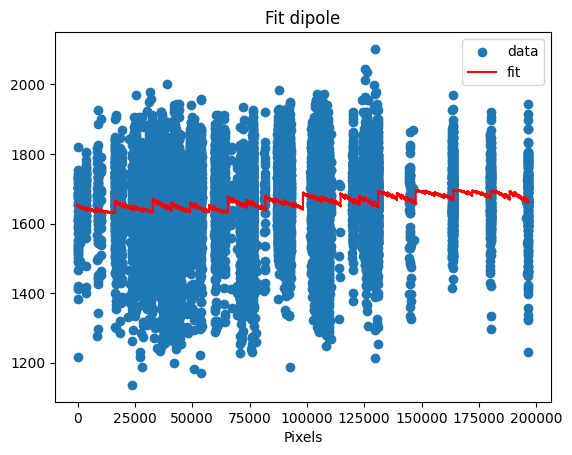

In [21]:
init =  (200, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title, weights=DR1_Mapper.FRACCOVnside)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1.259e+05 (χ²/ndof = 0.6)  │              Nfcn = 642              │
│ EDM = 1.18e-06 (Goal: 0.0002)    │           time = 23.7 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 1.65701e3 │ 0.00032e3 │ -0.00032e3 │ 0.00032e3  │    0    │         │       │
│ 1 │ A    │  10e-12   │8292248e-12│  -10e-12   │8292248e-12 │    0    │    1    │       │
│ 2 │ ra   │    90     │    320    │    -90     │    270     │    0    │   360   │       │
│ 3 │ dec  │    81     │    165    │    -165    │     9      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.32   │   0.32    │  -10e-12  │8292248e-12│    -90    │    270    │   -165    │     9     │
│  Valid   │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   False   │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   True    │   True    │   False   │   True    │   False   │   False   │   True    │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────────────┐
│     │              N*               A              ra             dec │
├─────┼─────────────────────────────────────────────────────────────────┤
│  N* │             0.1     1.46104e-12            -0.0           -0.00 │
│   A │     1.46104e-12        3.24e-16 -66.33026164e-9  -1.67675771e-9 │
│  ra │            -0.0 -66.33026164e-9        9.55e+04             0e3 │
│ dec │           -0.00  -1.67675771e-9             0e3        6.05e+03 │
└─────┴─────────────────────────────────────────────────────────────────┘

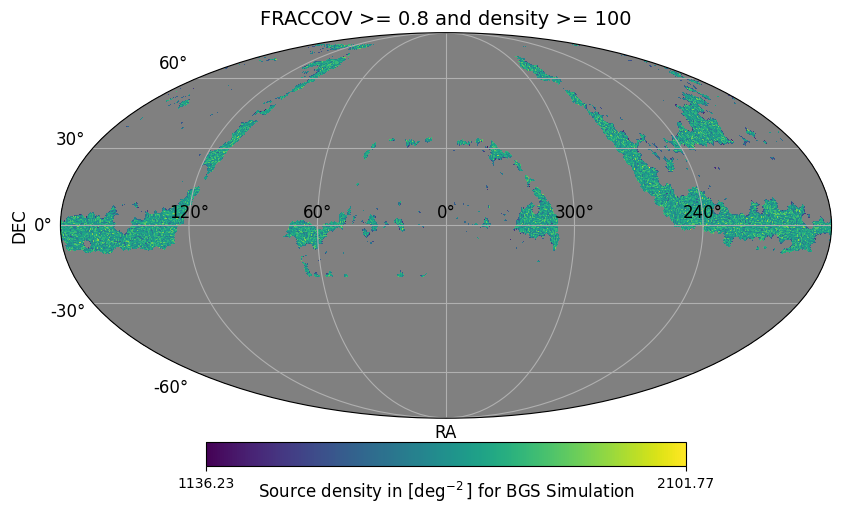

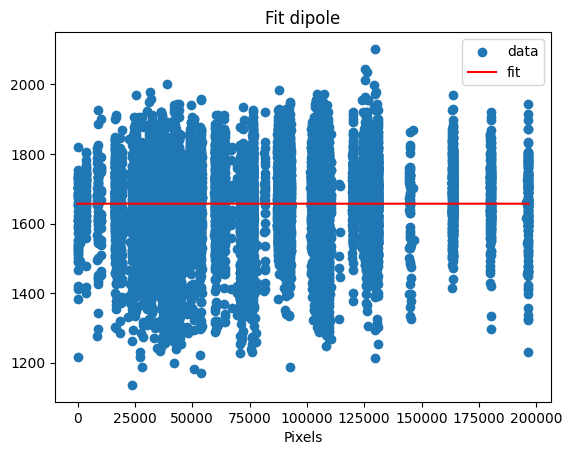

In [22]:
init =  (200, 0, 100, -10)
m = simu_Mapper_scale.fit_dipole("Cut", init, title_map=title)
m

## Introducing clustering

In [23]:
DIRcl = "Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "zmin0.1"
FILEcl = DIRcl + sufix + '.fits'

data = fitsio.FITS(FILEcl)
data


  file: Simulation/Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_zmin0.1.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY

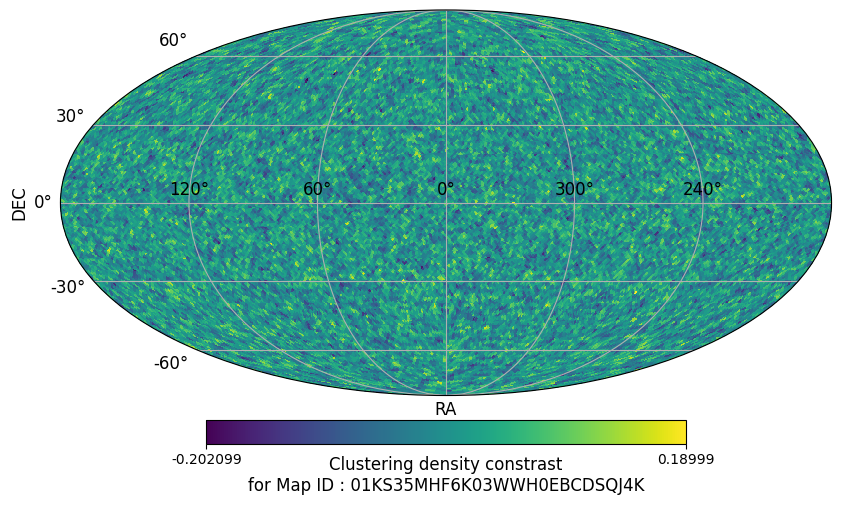

In [24]:
from Simulation.mappers import CountMapper

mapID, hpmap = data['MAPS'][0] #first clustering map
hpmap = hp.reorder(hpmap, r2n=True)
clMapper = CountMapper.from_map(hpmap)
clMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nfor Map ID : {mapID}")
clMapper.plot()

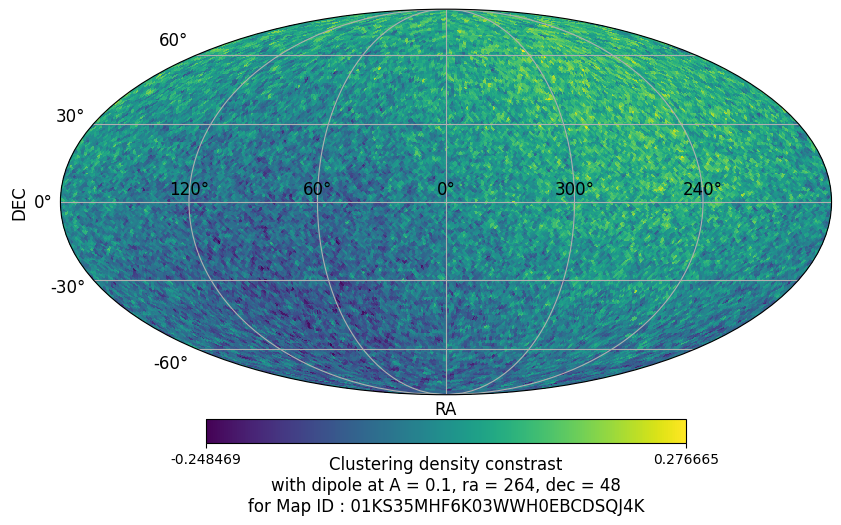

In [25]:
A, ra, dec = 0.1, 264, 48
clDipole = apply_dipole_MD(clMapper.map, clMapper.map, A, ra, dec, nest=True)
clDipoleMapper = CountMapper.from_map(clDipole)
clDipoleMapper._set_instance_settingsPlot(unit = f"Clustering density constrast\nwith dipole at A = {A}, ra = {ra}, dec = {dec}\nfor Map ID : {mapID}")
clDipoleMapper.plot()

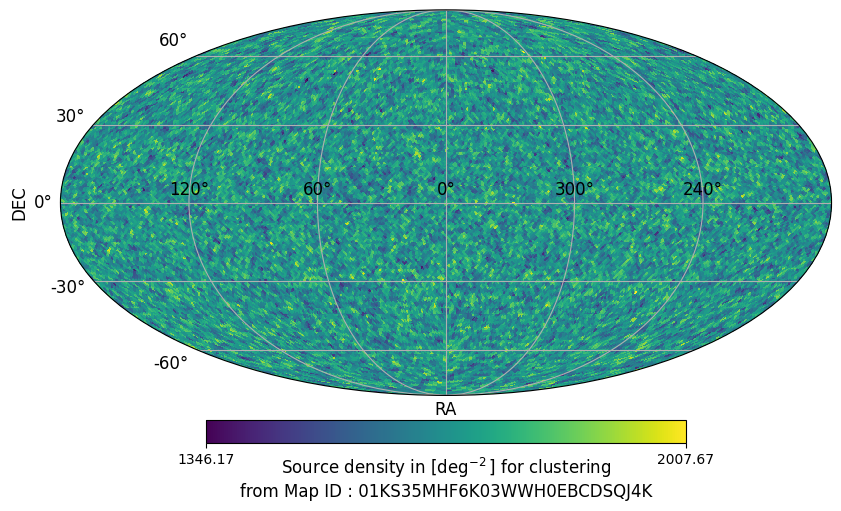

In [26]:
clMonop = apply_monopole_Mcontrast(clMapper.map, NSource_px_th/area_deg2)
clMonopMapper = DensityMapper.from_map(clMonop)
clMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}")
clMonopMapper.plot()

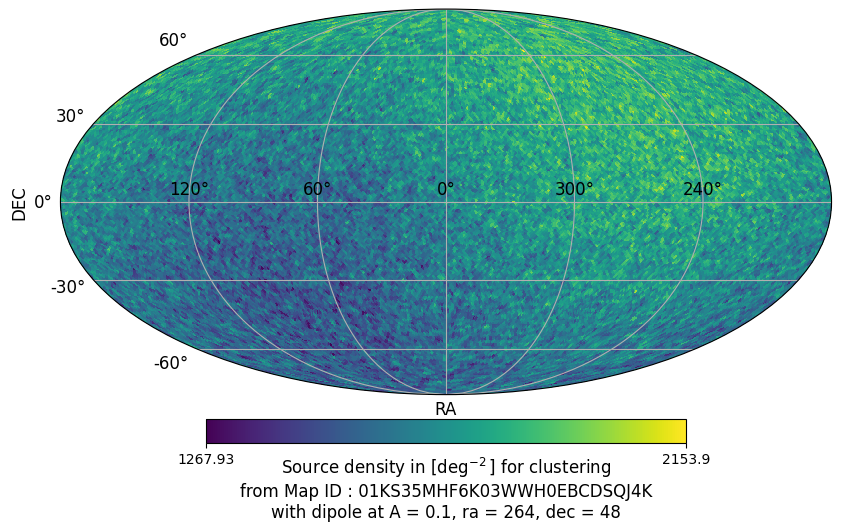

In [27]:
clDipMonop = apply_monopole_Mcontrast(clDipoleMapper.map, NSource_px_th/area_deg2)
clDipMonopMapper = DensityMapper.from_map(clDipMonop)
clDipMonopMapper._set_suffixTextPlot(unit = f"clustering\nfrom Map ID : {mapID}\nwith dipole at A = {A}, ra = {ra}, dec = {dec}")
clDipMonopMapper.plot()